# dmpbridge — Comparison Dashboard

All models and inference strategies in one view.

| Provider | Model | Strategy | Data |
|---|---|---|---|
| Ollama | llama3.3:70b | Batched | always available |
| Ollama | llama3.3:70b | Whole-doc | run `run_wholedoc_ollama.py --model llama3.3:70b` |
| Ollama | llama3.1:8b | Batched | always available |
| Ollama | llama3.1:8b | Whole-doc | run `run_wholedoc_ollama.py --model llama3.1:8b` |
| Anthropic | claude-opus-4-8 | Batched | always available |
| Anthropic | claude-opus-4-8 | Whole-doc | always available |

Sections: **1** Executive summary · **2** Per-sample accuracy · **3** F1 per label · **4** Cross-model agreement · **5** Error drill-down

In [ ]:
import sys
sys.path.insert(0, "../..")

from evaluate import extract_gold, evaluate_sample, match, LABELS, SHORT, LLM_DIR, MANUAL_DIR, NO_MATCH
import json
from collections import defaultdict
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="ticks", palette="muted")
plt.rcParams.update({
    "figure.facecolor":"white", "axes.facecolor":"white",
    "axes.edgecolor":"#555555", "axes.linewidth":0.8,
    "grid.color":"#dddddd",    "grid.linewidth":0.5,
    "text.color":"#111111",    "axes.labelcolor":"#111111",
    "xtick.color":"#111111",   "ytick.color":"#111111",
    "font.size":11, "axes.titlesize":13, "axes.labelsize":11,
    "xtick.labelsize":10, "ytick.labelsize":10,
    "legend.fontsize":9, "legend.frameon":True,
    "figure.dpi":120,
})

# ── Model registry ─────────────────────────────────────────────────────────────
# display_name -> (file_tag, bar_color, provider)
# File tags match data/llmlabeled/sampleN_{tag}.json
ALL_MODELS = {
    "llama3.3 batch":     ("llama3.3-70b_batch",      "#1d4ed8", "Ollama"),
    "llama3.3 whole-doc": ("llama3.3-70b_whole_doc",  "#60a5fa", "Ollama"),
    "llama3.1 batch":     ("llama3.1-8b_batch",       "#0369a1", "Ollama"),
    "llama3.1 whole-doc": ("llama3.1-8b_whole_doc",   "#7dd3fc", "Ollama"),
    "claude batch":       ("claude-opus-4-8_batch",    "#7c3aed", "Anthropic"),
    "claude whole-doc":   ("claude-opus-4-8_whole_doc","#c084fc", "Anthropic"),
}

def _snum(p):
    s = p.stem if hasattr(p, "stem") else p
    return int(s.replace("_dmp","").replace("sample",""))

samples = sorted(MANUAL_DIR.glob("*_dmp.json"), key=_snum)

def _f1(conf, lbl):
    tp = conf.get(lbl,{}).get(lbl,0)
    fp = sum(conf.get(o,{}).get(lbl,0) for o in LABELS if o!=lbl)
    fn = sum(v for p,v in conf.get(lbl,{}).items() if p!=lbl)
    p_ = tp/(tp+fp) if (tp+fp) else 0.
    r_ = tp/(tp+fn) if (tp+fn) else 0.
    return 2*p_*r_/(p_+r_) if (p_+r_) else 0.

def load_variant(tag):
    rows, conf = [], defaultdict(lambda: defaultdict(int))
    for mp in samples:
        stem = mp.stem.replace("_dmp","")
        pp   = LLM_DIR / f"{stem}_{tag}.json"
        if not pp.exists(): continue
        gold = extract_gold(mp)
        c    = evaluate_sample(pp, gold)
        for tl,preds in c.items():
            for pl,cnt in preds.items():
                conf[tl][pl] += cnt
        tp = sum(c.get(l,{}).get(l,0) for l in LABELS)
        n  = sum(sum(v.values()) for v in c.values())
        rows.append({"sample":stem,"total":n,"correct":tp,
                     "errors":n-tp,"accuracy":tp/n if n else 0})
    return (pd.DataFrame(rows), conf) if rows else (None, None)

# Load all variants — skip missing data silently
variants = {name: load_variant(tag) for name,(tag,_,_) in ALL_MODELS.items()}
ACTIVE   = {n: v for n,v in variants.items() if v[0] is not None}

print("Available variants:")
last_grp = None
for name, (tag, color, grp) in ALL_MODELS.items():
    if grp != last_grp: print(f"  [{grp}]"); last_grp = grp
    df, _ = variants[name]
    if df is None:
        print(f"    {name:<22}  -- not available --")
    else:
        tc,tn = int(df['correct'].sum()), int(df['total'].sum())
        print(f"    {name:<22}  {tc}/{tn}  ({tc/tn*100:.1f}%)")

## 1 — Executive Summary

Key metrics for deciding which model/strategy to deploy:  
- **q.text F1** — hardest label; drives most errors  
- **sec.desc F1** — closely related to q.text; both improve dramatically with whole-doc context  
- **ans.text F1** — usually high across all models; not a differentiator

In [2]:
print("=" * 92)
print("  dmpbridge — Model Comparison")
print("=" * 92)
hdr = f"  {'Provider':<10}  {'Variant':<22}  {'Accuracy':>8}  {'q.text F1':>10}  {'sec.desc F1':>12}  {'ans.text F1':>12}"
print("\n" + hdr)
print("  " + "-" * 84)
last_grp = None
for name, (df, conf) in ACTIVE.items():
    tag, color, grp = ALL_MODELS[name]
    if grp != last_grp:
        if last_grp: print()
        last_grp = grp
    tc, tn = int(df['correct'].sum()), int(df['total'].sum())
    acc = tc/tn*100
    print(f"  {grp:<10}  {name:<22}  {acc:>7.1f}%"
          f"  {_f1(conf,'question.text')*100:>9.1f}%"
          f"  {_f1(conf,'section.description')*100:>11.1f}%"
          f"  {_f1(conf,'answer.text')*100:>11.1f}%")
print("=" * 92)

  dmpbridge — Model Comparison

  Provider    Variant                 Accuracy   q.text F1   sec.desc F1   ans.text F1
  ------------------------------------------------------------------------------------
  Ollama      llama3.3 batch             94.1%       70.7%         87.7%         99.0%
  Ollama      llama3.1 batch             67.3%       26.1%         40.5%         80.2%

  Anthropic   claude batch               94.9%       62.0%         84.4%         99.9%
  Anthropic   claude whole-doc           96.9%       88.2%         99.1%         99.6%


## 2 — Per-sample accuracy

Solid bars = batched, hatched bars = whole-doc.  
Look for samples where batched and whole-doc diverge — those are documents where structural context matters most.

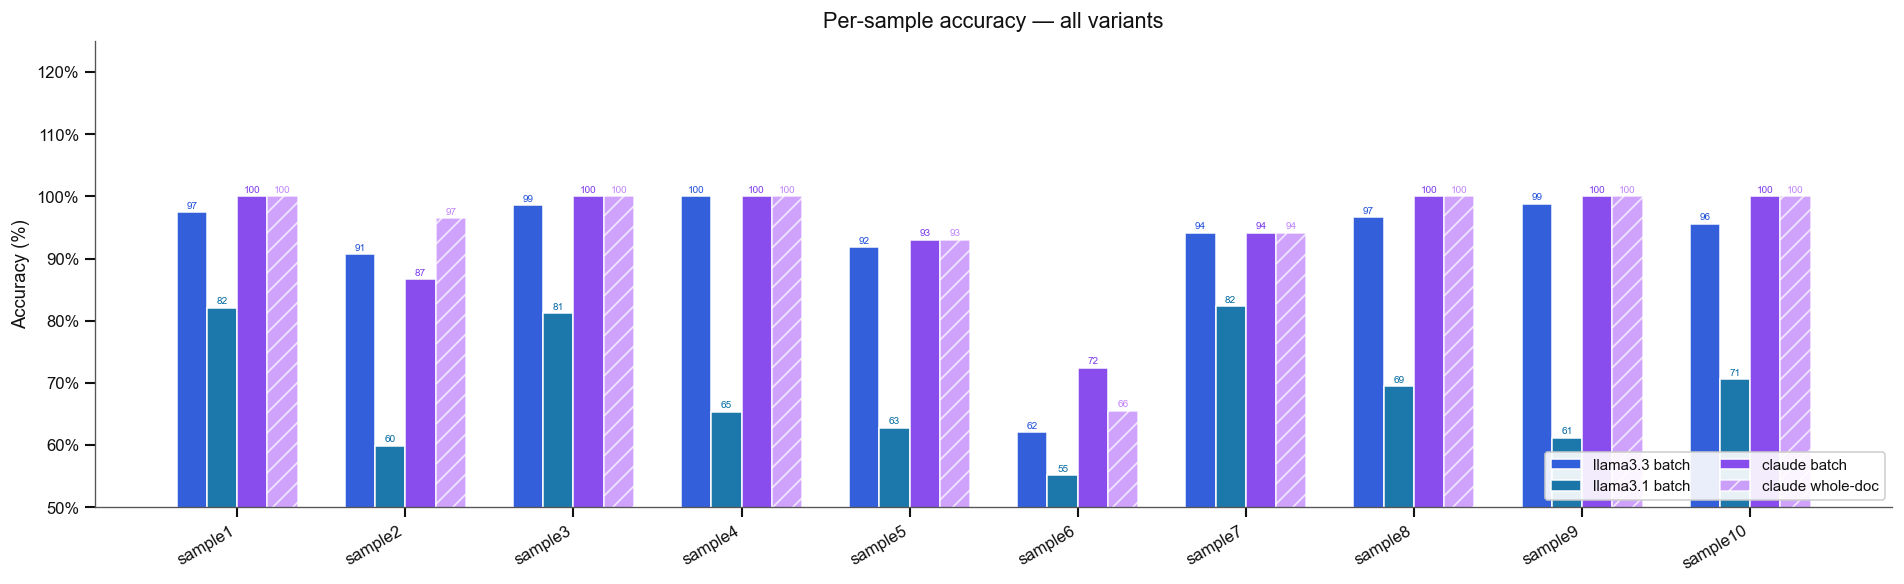

In [3]:
n_active = len(ACTIVE)
w        = min(0.8 / n_active, 0.18)
x_lbls   = sorted(next(iter(ACTIVE.values()))[0]["sample"].tolist(), key=_snum)
x        = range(len(x_lbls))

fig, ax = plt.subplots(figsize=(16, 5))
for i, (name, (df, _)) in enumerate(ACTIVE.items()):
    tag, color, grp = ALL_MODELS[name]
    # linestyle: solid for batch, dashed for whole-doc
    alpha  = 0.9 if "batch" in name else 0.75
    hatch  = None if "batch" in name else "//"
    dfs    = df.set_index("sample").reindex(x_lbls).reset_index()
    offset = (i - n_active/2 + 0.5) * w
    bars   = ax.bar([xi + offset for xi in x], dfs["accuracy"]*100,
                    width=w, label=name, color=color, edgecolor="white",
                    alpha=alpha, hatch=hatch)
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x()+bar.get_width()/2, h+0.3,
                    f"{h:.0f}", ha="center", va="bottom", fontsize=6, color=color)

ax.set_xticks(list(x)); ax.set_xticklabels(x_lbls, rotation=30, ha="right")
ax.set_ylim(50, 125); ax.set_ylabel("Accuracy (%)")
ax.set_title("Per-sample accuracy — all variants", pad=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:.0f}%"))
ax.legend(framealpha=0.9, ncol=2, loc="lower right")
sns.despine(); plt.tight_layout(); plt.show()

## 3 — Per-label F1

F1 tells you **per-label reliability** not captured by overall accuracy.  
A model with 94% accuracy but 60% q.text F1 will visibly mislabel sub-question prompts in output.

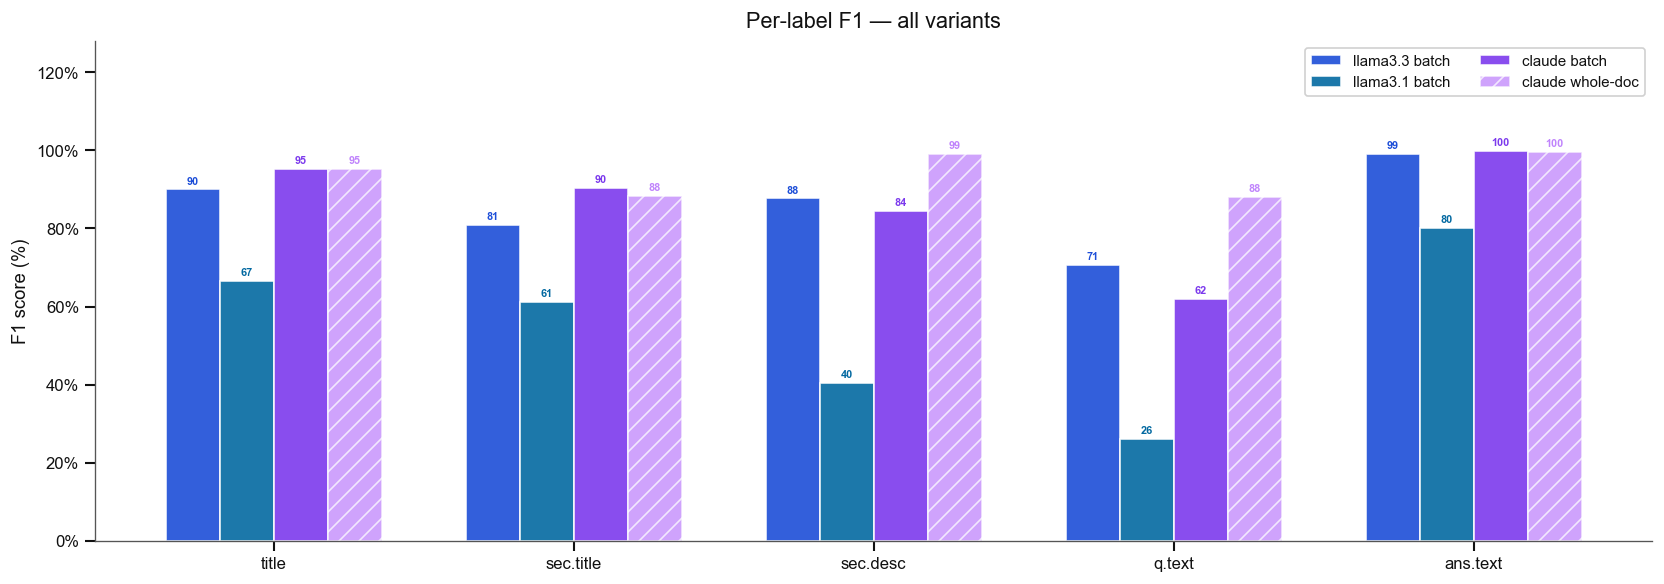

Label                           llama3.3 batch          llama3.1 batch            claude batch        claude whole-doc
----------------------------------------------------------------------------------------------------------------------
title                                     90.0%                    66.7%                    95.2%                    95.2%
section.title                             80.9%                    61.3%                    90.5%                    88.4%
section.description                       87.7%                    40.5%                    84.4%                    99.1%
question.text                             70.7%                    26.1%                    62.0%                    88.2%
answer.text                               99.0%                    80.2%                    99.9%                    99.6%
----------------------------------------------------------------------------------------------------------------------
OVERALL accuracy            

In [4]:
fig, ax = plt.subplots(figsize=(14, 5))
x2 = range(len(LABELS))
w2 = min(0.8 / n_active, 0.18)

for i, (name, (_, conf)) in enumerate(ACTIVE.items()):
    tag, color, grp = ALL_MODELS[name]
    alpha  = 0.9 if "batch" in name else 0.75
    hatch  = None if "batch" in name else "//"
    f1_vals = [_f1(conf, l)*100 for l in LABELS]
    offset  = (i - n_active/2 + 0.5) * w2
    bars    = ax.bar([xi + offset for xi in x2], f1_vals,
                     width=w2, label=name, color=color,
                     edgecolor="white", alpha=alpha, hatch=hatch)
    for bar, v in zip(bars, f1_vals):
        if v > 0:
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
                    f"{v:.0f}", ha="center", va="bottom",
                    fontsize=6.5, fontweight="bold", color=color)

ax.set_xticks(list(x2)); ax.set_xticklabels(SHORT, fontsize=10)
ax.set_ylim(0, 128); ax.set_ylabel("F1 score (%)")
ax.set_title("Per-label F1 — all variants", pad=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:.0f}%"))
ax.legend(framealpha=0.9, ncol=2)
sns.despine(); plt.tight_layout(); plt.show()

# F1 table
col_w = 22
print(f"{'Label':<22}" + "".join(f"  {n:>{col_w}}" for n in ACTIVE))
print("-" * (22 + (col_w+2)*n_active))
for lbl in LABELS:
    row = f"{lbl:<22}"
    for name, (_, conf) in ACTIVE.items():
        row += f"  {_f1(conf,lbl)*100:>{col_w}.1f}%"
    print(row)
print("-" * (22 + (col_w+2)*n_active))
row = f"{'OVERALL accuracy':<22}"
for name, (df, _) in ACTIVE.items():
    ov = df['correct'].sum()/df['total'].sum()*100
    row += f"  {ov:>{col_w}.1f}%"
print(row)

## 4 — Cross-model agreement

For each block (matched to gold), counts how many **active** variants labeled it correctly.

Counts how many **active variants** labeled each block correctly.  
- **all correct** — easy blocks; any model handles them  
- **1–2 correct** — ambiguous blocks; model choice matters  
- **all wrong** — genuinely hard blocks; may need prompt engineering or label definition revision

In [5]:
tag_list   = [(n, ALL_MODELS[n][0]) for n in ACTIVE]
cross_rows = []

for mp in samples:
    stem = mp.stem.replace("_dmp","")
    gold = extract_gold(mp)
    bsets = {}
    for name, tag in tag_list:
        pp = LLM_DIR / f"{stem}_{tag}.json"
        if pp.exists():
            bsets[name] = json.loads(pp.read_text(encoding="utf-8"))
    if not bsets: continue
    # Use first available as block reference
    ref_name = next(iter(bsets))
    for idx, b in enumerate(bsets[ref_name]):
        true_lbl = match(b["text"], gold)
        if true_lbl is None: continue
        preds     = {n: bsets[n][idx].get("label","answer.text")
                     for n in bsets if idx < len(bsets[n])}
        n_correct = sum(1 for p in preds.values() if p == true_lbl)
        row = {"sample":stem, "text":b["text"][:100],
               "page":b.get("page","-"), "true":true_lbl, "n_correct":n_correct}
        for n,_ in tag_list:
            row[f"pred_{n.replace(' ','_')}"] = preds.get(n,"--")
        cross_rows.append(row)

df_cross = pd.DataFrame(cross_rows)
total    = len(df_cross)
print(f"Cross-model agreement  ({n_active} variants, {total} matched blocks)\n")
for n in range(n_active, -1, -1):
    lbl = {n_active:"all correct", 0:"all wrong"}.get(n, f"{n} correct")
    cnt = (df_cross["n_correct"]==n).sum()
    pct = cnt/total*100
    bar = chr(9608)*int(pct/2)
    print(f"  {lbl:<14} {cnt:>4}  ({pct:>5.1f}%)  {bar}")
print(f"\nBlocks all variants got wrong: {(df_cross['n_correct']==0).sum()}")

Cross-model agreement  (4 variants, 726 matched blocks)

  all correct     481  ( 66.3%)  █████████████████████████████████
  3 correct       213  ( 29.3%)  ██████████████
  2 correct        24  (  3.3%)  █
  1 correct         6  (  0.8%)  
  all wrong         2  (  0.3%)  

Blocks all variants got wrong: 2


C:\Users\Nahid\AppData\Local\Temp\ipykernel_39540\1785181891.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_lbl2, rotation=30, ha="right")


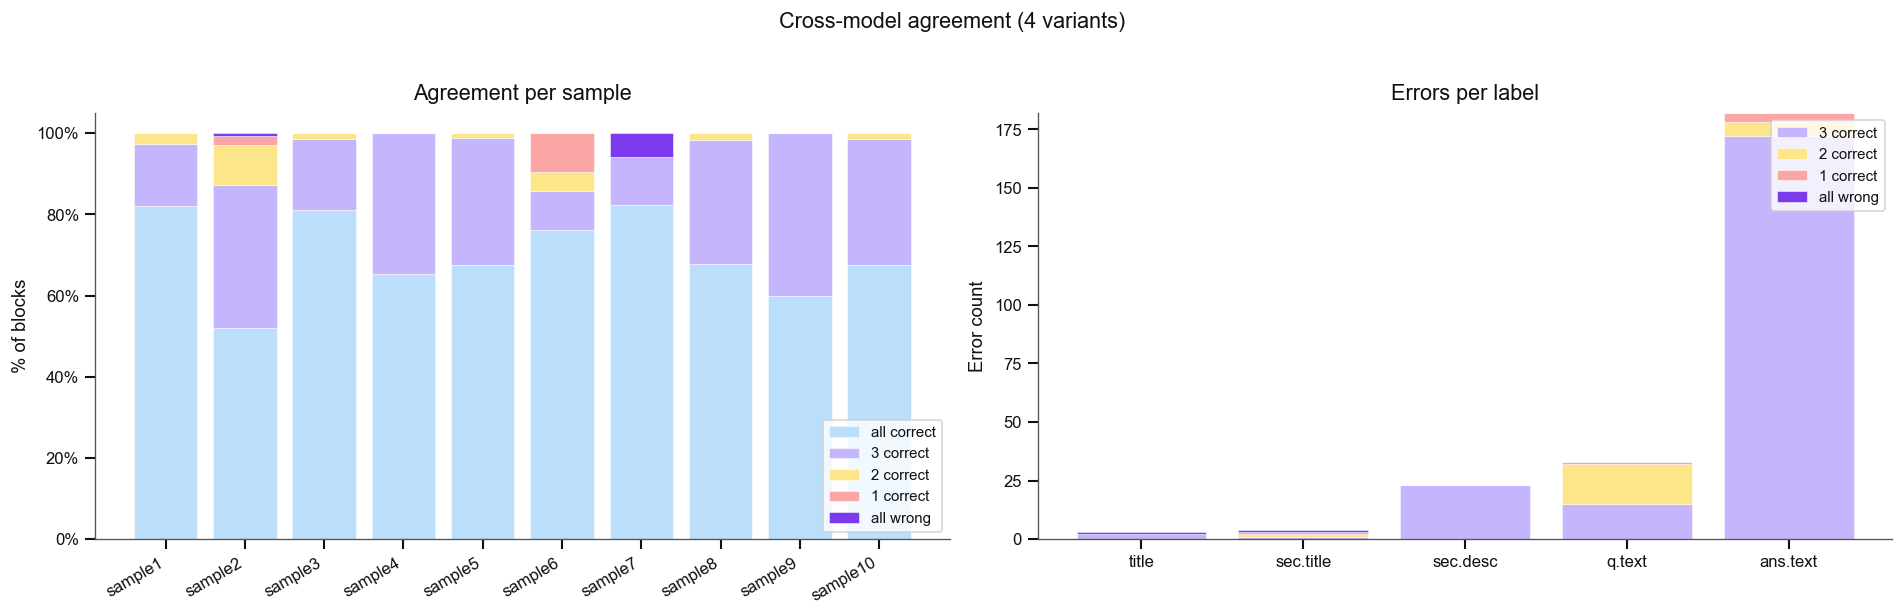

In [6]:
# Agreement stacked bar — colour by n_correct bucket
palette = [
    "#bbdefb",   # all correct — light blue
    "#c4b5fd",   # n-1 correct
    "#fde68a",   # n-2 correct
    "#fca5a5",   # 1 correct
    "#7c3aed",   # all wrong — deep purple
]
levels = [n_active, n_active-1, n_active-2, 1, 0]
levels = [n for n in levels if n >= 0]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Stacked bar per sample
ax = axes[0]
x_lbl2  = sorted(df_cross["sample"].unique(), key=_snum)
bottoms = {s: 0 for s in x_lbl2}
for n, color in zip(levels, palette):
    lbl = {n_active:"all correct", 0:"all wrong"}.get(n, f"{n} correct")
    vals = [(df_cross[df_cross["sample"]==s]["n_correct"]==n).sum() /
            max(len(df_cross[df_cross["sample"]==s]),1) * 100 for s in x_lbl2]
    ax.bar(x_lbl2, vals, bottom=[bottoms[s] for s in x_lbl2],
           label=lbl, color=color, edgecolor="white", linewidth=0.3)
    for s,v in zip(x_lbl2,vals): bottoms[s]+=v
ax.set_ylim(0,105); ax.set_ylabel("% of blocks")
ax.set_title("Agreement per sample", pad=8)
ax.set_xticklabels(x_lbl2, rotation=30, ha="right")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:.0f}%"))
ax.legend(loc="lower right", fontsize=9); sns.despine(ax=ax)

# Per-label error breakdown
ax = axes[1]
btm = [0]*len(LABELS)
for n, color in list(zip(levels, palette))[1:]:  # skip "all correct"
    lbl = {0:"all wrong"}.get(n, f"{n} correct")
    vals = [(df_cross[df_cross["true"]==l]["n_correct"]==n).sum() for l in LABELS]
    ax.bar(range(len(LABELS)), vals, bottom=btm, label=lbl,
           color=color, edgecolor="white", linewidth=0.3)
    btm = [b+v for b,v in zip(btm,vals)]
ax.set_xticks(range(len(LABELS))); ax.set_xticklabels(SHORT, fontsize=10)
ax.set_ylabel("Error count")
ax.set_title("Errors per label", pad=8)
ax.legend(loc="upper right", fontsize=9); sns.despine(ax=ax)

plt.suptitle(f"Cross-model agreement ({n_active} variants)", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

## 5 — Error drill-down

Edit the filter cells below to inspect any specific error pattern.

In [7]:
FILTER_VARIANT = "claude whole-doc"  # display name from ALL_MODELS, or "" for all
FILTER_TRUE    = "question.text"      # label or "" for all
FILTER_PRED    = ""                   # label or "" for all
FILTER_SAMPLE  = ""                   # e.g. "sample2" or ""
ONLY_ERRORS    = True

pred_col = f"pred_{FILTER_VARIANT.replace(' ','_')}" if FILTER_VARIANT else None
pred_cols = [c for c in df_cross.columns if c.startswith("pred_")]

mask = pd.Series([True]*len(df_cross), index=df_cross.index)
if ONLY_ERRORS:
    if pred_col and pred_col in df_cross.columns:
        mask &= df_cross[pred_col] != df_cross["true"]
    else:
        mask &= df_cross["n_correct"] < n_active
if FILTER_TRUE:   mask &= df_cross["true"]   == FILTER_TRUE
if FILTER_SAMPLE: mask &= df_cross["sample"] == FILTER_SAMPLE
if FILTER_PRED and pred_col and pred_col in df_cross.columns:
    mask &= df_cross[pred_col] == FILTER_PRED

subset = df_cross[mask].reset_index(drop=True)
print(f"variant={FILTER_VARIANT or 'all'}  true={FILTER_TRUE or 'any'}  "
      f"pred={FILTER_PRED or 'any'}  sample={FILTER_SAMPLE or 'all'}")
print(f"Matching blocks: {len(subset)}\n")
if not subset.empty:
    pd.set_option("display.max_colwidth", 90)
    display(subset[["sample","page","true","n_correct"]+pred_cols+["text"]])

variant=claude whole-doc  true=question.text  pred=any  sample=all
Matching blocks: 0

